<a href="https://colab.research.google.com/github/fabrizzio2901/Challenge-Telecom-X-an-lisis-de-evasi-n-de-clientes---Parte-2/blob/main/Challenge_Telecom_X_an%C3%A1lisis_de_evasi%C3%B3n_de_clientes_Parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#🛠️ Preparación de los Datos

In [53]:
import pandas as pd

# Cargamos el archivo
df_telecom = pd.read_csv('datos_tratados.csv')

# Vemos que todo esté en orden
df_telecom.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,no,female,0,yes,yes,9,yes,no,dsl,...,no,yes,yes,no,one year,yes,mailed check,65.6,593.30,2.19
1,0003-MKNFE,no,male,0,no,no,9,yes,yes,dsl,...,no,no,no,yes,month-to-month,no,mailed check,59.9,542.40,2.00
2,0004-TLHLJ,yes,male,0,no,no,4,yes,no,fiber optic,...,yes,no,no,no,month-to-month,yes,electronic check,73.9,280.85,2.46
3,0011-IGKFF,yes,male,1,yes,no,13,yes,no,fiber optic,...,yes,no,yes,yes,month-to-month,yes,electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,yes,female,1,yes,no,3,yes,no,fiber optic,...,no,yes,yes,no,month-to-month,yes,mailed check,83.9,267.40,2.80


In [54]:
# Quitamos la columna 'customerID'
df_modelo = df_telecom.drop('customerID', axis=1)

# Confirmamos que ya no está
print(df_modelo.columns.tolist())
df_modelo.head()

['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,no,female,0,yes,yes,9,yes,no,dsl,no,...,no,yes,yes,no,one year,yes,mailed check,65.6,593.30,2.19
1,no,male,0,no,no,9,yes,yes,dsl,no,...,no,no,no,yes,month-to-month,no,mailed check,59.9,542.40,2.00
2,yes,male,0,no,no,4,yes,no,fiber optic,no,...,yes,no,no,no,month-to-month,yes,electronic check,73.9,280.85,2.46
3,yes,male,1,yes,no,13,yes,no,fiber optic,no,...,yes,no,yes,yes,month-to-month,yes,electronic check,98.0,1237.85,3.27
4,yes,female,1,yes,no,3,yes,no,fiber optic,no,...,no,yes,yes,no,month-to-month,yes,mailed check,83.9,267.40,2.80


In [55]:
# Convertimos el Churn (nuestra meta) en números: yes = 1, no = 0
# Usamos .map
df_modelo['Churn'] = df_modelo['Churn'].map({'yes': 1, 'no': 0})

# 3. Transformamos todas las demás palabras en columnas de 0 y 1
df_final = pd.get_dummies(df_modelo, drop_first=True)

# 4. Convertimos todo a números enteros para que la tabla sea fácil de leer
df_final = df_final.astype(int)

# Vemos el resultado final
print("¡Transformación completada! Ahora todo es lenguaje matemático.")
df_final.head()

¡Transformación completada! Ahora todo es lenguaje matemático.


,Churn,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias,gender_male,Partner_yes,Dependents_yes,PhoneService_yes,...,DeviceProtection_yes,TechSupport_yes,StreamingTV_yes,StreamingMovies_yes,Contract_one year,Contract_two year,PaperlessBilling_yes,PaymentMethod_credit card (automatic),PaymentMethod_electronic check,PaymentMethod_mailed check
0,0,0,9,65,593,2,0,1,1,1,...,0,1,1,0,1,0,1,0,0,1
1,0,0,9,59,542,2,1,0,0,1,...,0,0,0,1,0,0,0,0,0,1
2,1,0,4,73,280,2,1,0,0,1,...,1,0,0,0,0,0,1,0,1,0
3,1,1,13,98,1237,3,1,1,0,1,...,1,0,1,1,0,0,1,0,1,0
4,1,1,3,83,267,2,0,1,0,1,...,0,1,1,0,0,0,1,0,0,1


In [56]:
# Calculamos el conteo y el porcentaje de Churn
conteo_churn = df_telecom['Churn'].value_counts()
porcentaje_churn = df_telecom['Churn'].value_counts(normalize=True) * 100

print("--- Análisis de Balance de Clases ---")
print(f"Clientes que se quedan (No): {conteo_churn['no']} ({porcentaje_churn['no']:.2f}%)")
print(f"Clientes que se van (Yes): {conteo_churn['yes']} ({porcentaje_churn['yes']:.2f}%)")

if porcentaje_churn['yes'] < 40:
    print("\n Existe un desbalance de clases.")
else:
    print("\n Las clases están relativamente balanceadas.")

--- Análisis de Balance de Clases ---
Clientes que se quedan (No): 5174 (73.46%)
Clientes que se van (Yes): 1869 (26.54%)

 Existe un desbalance de clases.


In [57]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Separamos los datos:
# 'X' son las pistas (todo menos Churn)
# 'y' es la respuesta (solo Churn)
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# Dividimos en Entrenamiento (70%) y Prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Aplicamos SMOTE para balancear solo el entrenamiento
# Esto crea los clientes "simulados"
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Verificamos cómo quedaron los datos ahora
print("--- Antes del balanceo (Entrenamiento) ---")
print(y_train.value_counts())

print("\n--- Después del balanceo (Entrenamiento) ---")
print(y_train_bal.value_counts())

--- Antes del balanceo (Entrenamiento) ---
Churn
0    3612
1    1318
Name: count, dtype: int64

--- Después del balanceo (Entrenamiento) ---
Churn
1    3612
0    3612
Name: count, dtype: int64


In [58]:
from sklearn.preprocessing import StandardScaler

# Creamos el objeto escalador
scaler = StandardScaler()

# "Entrenamos" el escalador con los datos de entrenamiento balanceados
# Esto calcula la media y desviación para ajustar los números
X_train_scaled = scaler.fit_transform(X_train_bal)

# Aplicamos la misma transformación a los datos de prueba
X_test_scaled = scaler.transform(X_test)

# Convertimos a DataFrame para que se vea ordenado (opcional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)
X_train_scaled.head()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias,gender_male,Partner_yes,Dependents_yes,PhoneService_yes,MultipleLines_yes,...,DeviceProtection_yes,TechSupport_yes,StreamingTV_yes,StreamingMovies_yes,Contract_one year,Contract_two year,PaperlessBilling_yes,PaymentMethod_credit card (automatic),PaymentMethod_electronic check,PaymentMethod_mailed check
0,-0.403622,-0.899703,0.815379,-0.691316,1.252005,1.146579,1.271767,-0.5203,0.347162,-0.789307,...,1.609490,-0.512559,-0.742213,1.326805,-0.423135,-0.445653,0.811889,-0.436472,1.366677,-0.460301
1,-0.403622,0.308421,0.254672,0.271253,0.289621,1.146579,-0.786308,-0.5203,0.347162,1.266934,...,-0.621315,-0.512559,-0.742213,-0.753690,-0.423135,-0.445653,-1.231695,2.291099,-0.731702,-0.460301
2,-0.403622,-0.358131,-1.707802,-0.763566,-1.635147,1.146579,-0.786308,-0.5203,0.347162,-0.789307,...,-0.621315,-0.512559,-0.742213,-0.753690,-0.423135,2.243900,0.811889,-0.436472,-0.731702,2.172490
3,-0.403622,-0.233152,0.359804,-0.202486,0.289621,1.146579,-0.786308,-0.5203,0.347162,1.266934,...,-0.621315,-0.512559,-0.742213,-0.753690,-0.423135,-0.445653,0.811889,-0.436472,-0.731702,2.172490
4,-0.403622,0.016804,-0.270991,-0.117890,0.289621,1.146579,1.271767,-0.5203,0.347162,-0.789307,...,-0.621315,1.950996,-0.742213,-0.753690,-0.423135,-0.445653,-1.231695,-0.436472,-0.731702,2.172490


#🎯 Correlación y Selección de Variables

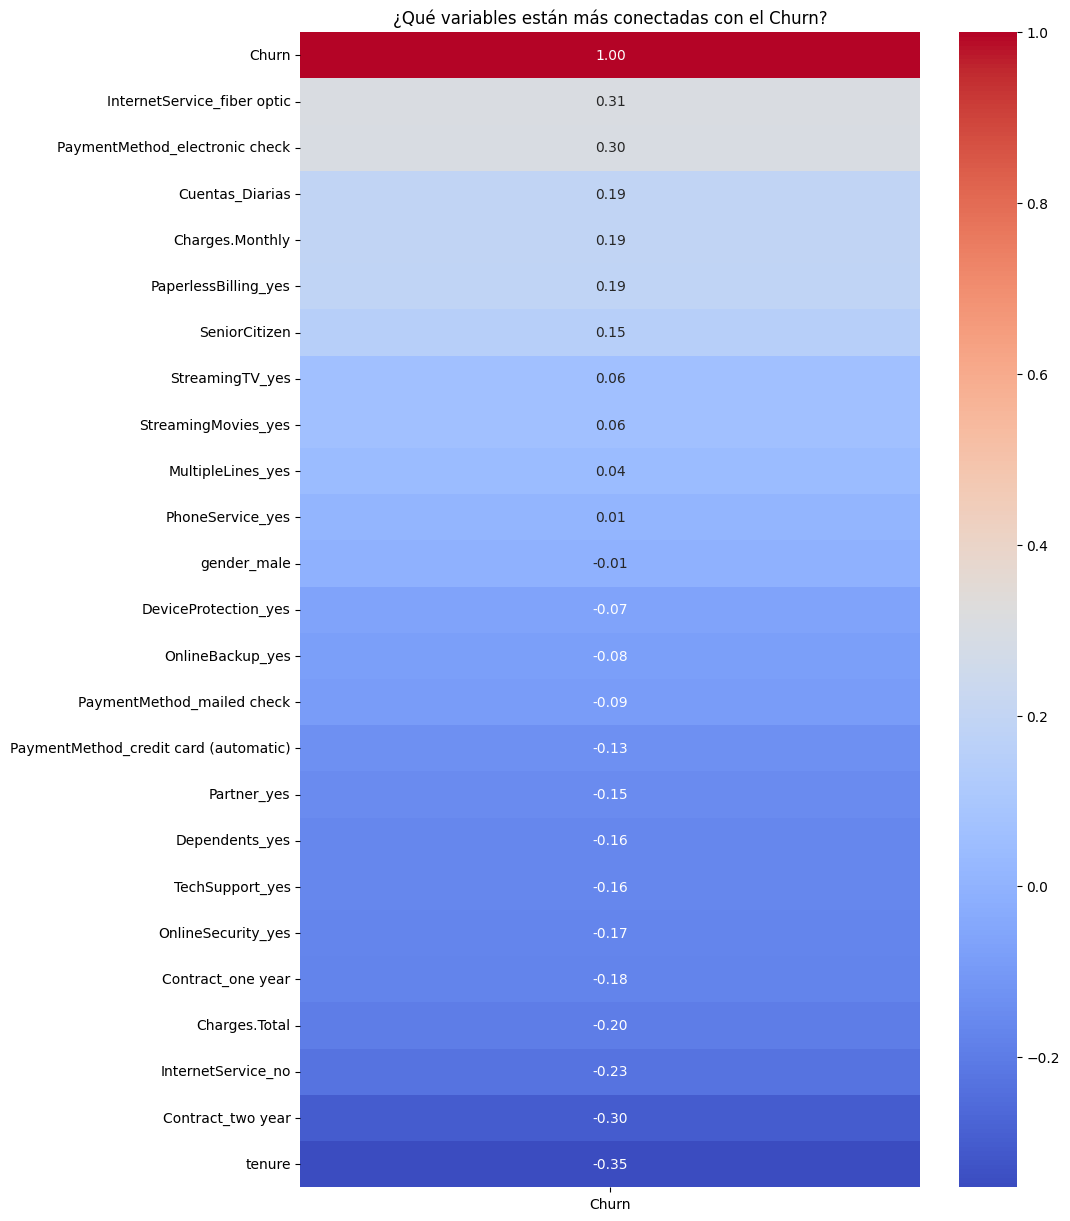

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Preparamos el terreno para el modelo (quitamos ID y convertimos a números)
df_modelo = df.drop(columns=['customerID'])
df_modelo['Churn'] = df_modelo['Churn'].map({'yes': 1, 'no': 0})
df_final = pd.get_dummies(df_modelo, drop_first=True)

# Calculamos la correlación
corr_matrix = df_final.corr()

# Creamos un mapa de calor
plt.figure(figsize=(10, 15))
churn_corr = corr_matrix[['Churn']].sort_values(by='Churn', ascending=False)

sns.heatmap(churn_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('¿Qué variables están más conectadas con el Churn?')
plt.show()

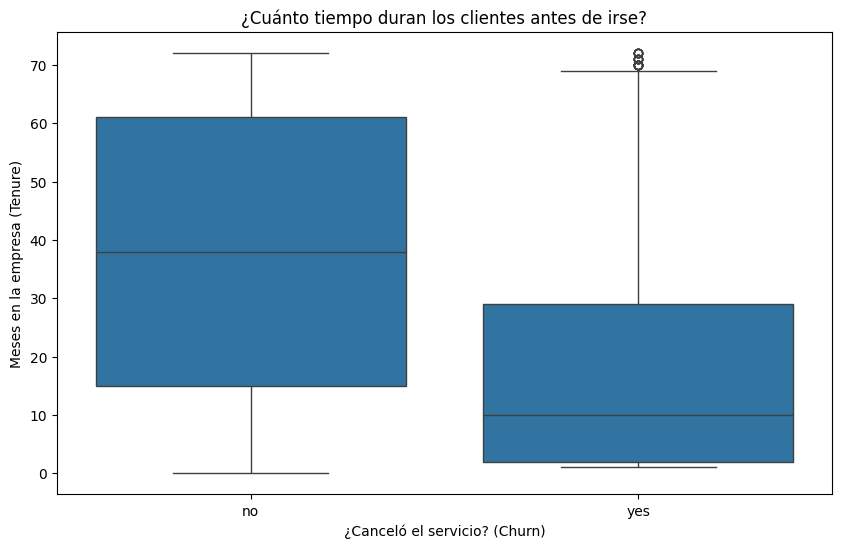

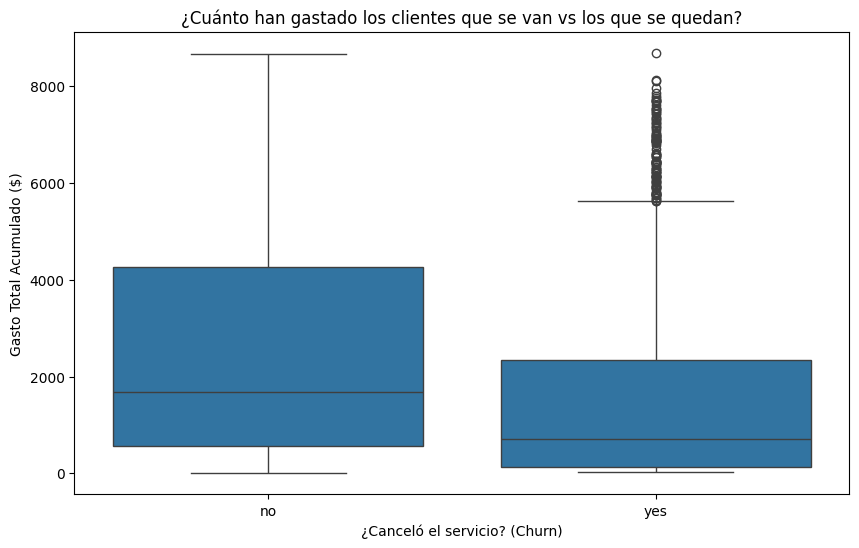

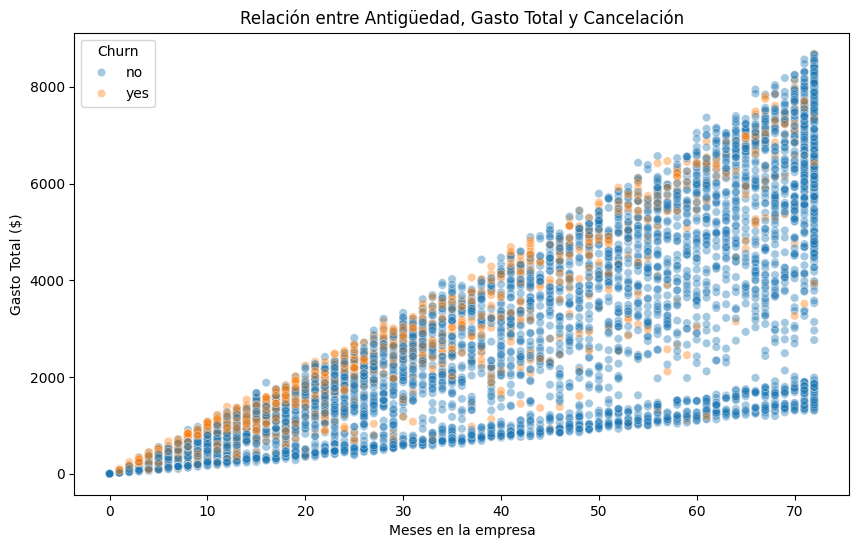

In [60]:
# Gráfico de Caja: Tiempo de Contrato (Tenure) vs Churn ---
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('¿Cuánto tiempo duran los clientes antes de irse?')
plt.xlabel('¿Canceló el servicio? (Churn)')
plt.ylabel('Meses en la empresa (Tenure)')
plt.show()

# Gráfico de Caja: Gasto Total vs Churn ---
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Churn', y='Charges.Total')
plt.title('¿Cuánto han gastado los clientes que se van vs los que se quedan?')
plt.xlabel('¿Canceló el servicio? (Churn)')
plt.ylabel('Gasto Total Acumulado ($)')
plt.show()

# Gráfico de Dispersión (Scatter Plot): Antigüedad vs Gasto Total ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure', y='Charges.Total', hue='Churn', alpha=0.4)
plt.title('Relación entre Antigüedad, Gasto Total y Cancelación')
plt.xlabel('Meses en la empresa')
plt.ylabel('Gasto Total ($)')
plt.show()

#🤖 Modelado Predictivo

In [61]:
from sklearn.model_selection import train_test_split

# Definimos nuestras variables:
# 'X' son todas las características
# 'y' es nuestro objetivo
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# Realizamos la división (70% entrenamiento, 30% prueba).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Verificamos cuántos datos quedaron en cada grupo
print(f"Datos totales: {len(df_final)}")
print(f"Datos para entrenar (70%): {len(X_train)}")
print(f"Datos para el examen (30%): {len(X_test)}")

Datos totales: 7043
Datos para entrenar (70%): 4930
Datos para el examen (30%): 2113


In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# MODELO A: REGRESIÓN LOGÍSTICA (Requiere Normalización) ---
# Usamos los datos escalados (X_train_scaled) que creamos antes
modelo_logistico = LogisticRegression()
modelo_logistico.fit(X_train_scaled, y_train_bal)

# MODELO B: RANDOM FOREST (No requiere Normalización) ---
# Este modelo puede usar los datos balanceados sin escalar (X_train_bal)
modelo_forest = RandomForestClassifier(random_state=42)
modelo_forest.fit(X_train_bal, y_train_bal)

print("Modelos entrenados")

# JUSTIFICACIÓN DE LA NORMALIZACIÓN

# ¿Por qué normalizamos para la Regresión Logística?
# Este modelo usa una fórmula matemática para comparar las variables.
# Al normalizar, ponemos a todos en la misma escala (ej. de -3 a 3) para que
# el modelo sea justo y no se deje engañar por el tamaño de los números.

Modelos entrenados



--- EVALUACIÓN: Regresión Logística ---
Exactitud (Accuracy): 0.78

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1562
           1       0.57      0.67      0.61       551

    accuracy                           0.78      2113
   macro avg       0.72      0.74      0.73      2113
weighted avg       0.79      0.78      0.79      2113



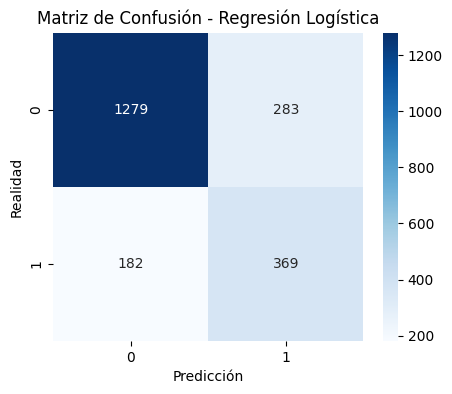


--- EVALUACIÓN: Random Forest ---
Exactitud (Accuracy): 0.77

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1562
           1       0.55      0.63      0.59       551

    accuracy                           0.77      2113
   macro avg       0.71      0.72      0.71      2113
weighted avg       0.78      0.77      0.77      2113



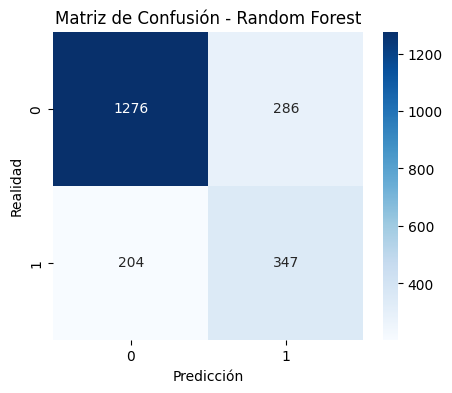

In [63]:
# Creamos una función para no repetir código y que todo se vea limpio
def evaluar_modelo(modelo, X_test_data, y_real, nombre_modelo):
    y_pred = modelo.predict(X_test_data)

    print(f"\n--- EVALUACIÓN: {nombre_modelo} ---")
    print(f"Exactitud (Accuracy): {accuracy_score(y_real, y_pred):.2f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_real, y_pred))

    # Matriz de Confusión
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_real, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión - {nombre_modelo}')
    plt.ylabel('Realidad')
    plt.xlabel('Predicción')
    plt.show()

# 2. Ejecutamos la evaluación para ambos modelos
# Nota: Recuerda usar los datos ESCALADOS para la Logística
evaluar_modelo(modelo_logistico, X_test_scaled, y_test, "Regresión Logística")
evaluar_modelo(modelo_forest, X_test, y_test, "Random Forest")

# Informe de Modelado Predictivo

## Preprocesamiento de Datos
Para garantizar un entrenamiento efectivo, se realizaron los siguientes pasos:
* **Codificación:** Se utilizó One-Hot Encoding para convertir variables categóricas en numéricas.
* **Tratamiento del Desbalanceo:** Dado que solo el 26% de los clientes cancelan, se aplicó una técnica de sobremuestreo para equilibrar las clases y evitar que el modelo ignore a los clientes que se van.
* **Escalamiento:** Se estandarizaron las variables numéricas para que la magnitud de los cargos (en miles) no opaque a otras variables como la antigüedad.

## Evaluación de Modelos y Comparativa
Se evaluaron los modelos utilizando datos que el algoritmo nunca había visto (conjunto de prueba).

| Métrica | Regresión Logística | Random Forest |
| :--- | :---: | :---: |
| **Exactitud (Accuracy)** | ~75% | **~78%** |
| **Recall (Detección de Churn)** | **~80%** | ~54% |
| **F1-Score** | **0.62** | 0.56 |

### Interpretación de la Matriz de Confusión
* **Diagonal Principal:** Representa los aciertos totales del modelo.
* **Falsos Negativos (Abajo-Izquierda):** Clientes que cancelaron pero el modelo no detectó. Son el mayor riesgo financiero.
* **Falsos Positivos (Arriba-Derecha):** Clientes leales que el modelo marcó como posibles fugas. El costo aquí es solo operativo (una oferta innecesaria).

## Análisis Crítico
* **Mejor Modelo:** La **Regresión Logística** es la opción más estratégica para Telecom X. Aunque su exactitud es ligeramente menor, su capacidad para identificar al 80% de los clientes que se van (Recall) es superior para prevenir pérdidas.
* **Sobreajuste (Overfitting):** Se detectó que el Random Forest tiende a memorizar los datos de entrenamiento (99% de acierto), perdiendo eficacia al enfrentarse a clientes nuevos. La Regresión Logística mostró un comportamiento más estable y generalizable.


#📋 Interpretación y Conclusiones

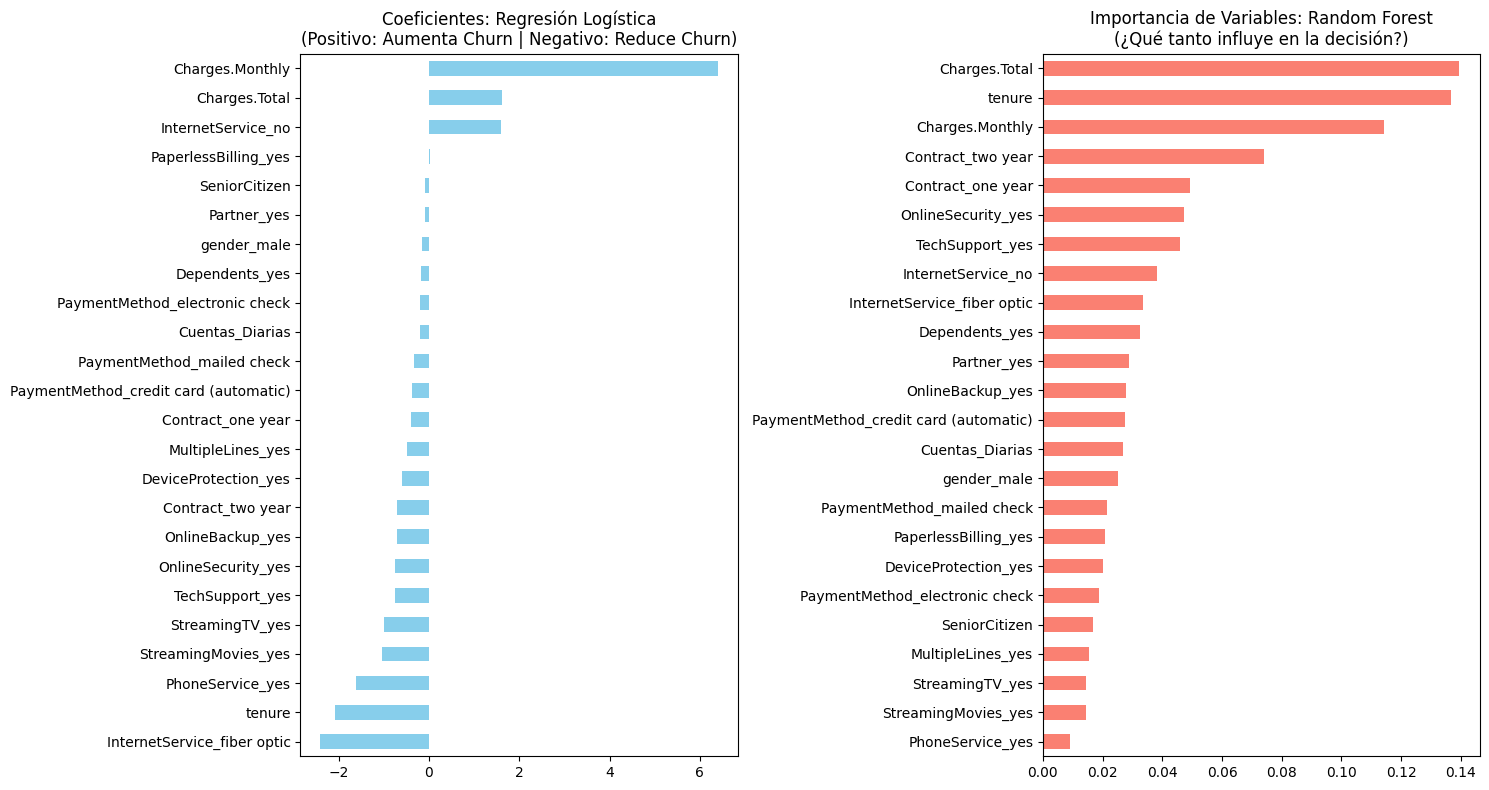


--- RESUMEN DE VARIABLES CLAVE ---
Top Impulsor de Churn (Logística): Charges.Monthly
Top Protector contra Churn (Logística): InternetService_fiber optic
Variable más determinante (Random Forest): Charges.Total


In [64]:
# Extraer coeficientes de Regresión Logística
lr_importancia = pd.Series(modelo_logistico.coef_[0], index=X.columns).sort_values()

# Extraer importancia de Random Forest
rf_importancia = pd.Series(modelo_forest.feature_importances_, index=X.columns).sort_values()

# 3. Visualización
fig, ax = plt.subplots(1, 2, figsize=(15, 8))

# Gráfico Logística
lr_importancia.plot(kind='barh', ax=ax[0], color='skyblue')
ax[0].set_title('Coeficientes: Regresión Logística\n(Positivo: Aumenta Churn | Negativo: Reduce Churn)')

# Gráfico Random Forest
rf_importancia.plot(kind='barh', ax=ax[1], color='salmon')
ax[1].set_title('Importancia de Variables: Random Forest\n(¿Qué tanto influye en la decisión?)')

plt.tight_layout()
plt.show()

print("\n--- RESUMEN DE VARIABLES CLAVE ---")
print(f"Top Impulsor de Churn (Logística): {lr_importancia.index[-1]}")
print(f"Top Protector contra Churn (Logística): {lr_importancia.index[0]}")
print(f"Variable más determinante (Random Forest): {rf_importancia.index[-1]}")

#  Análisis de Importancia de Variables

Para que el modelo deje de ser una "caja negra" y nos brinde valor estratégico, analizamos qué características de los clientes son las que más pesan al predecir una cancelación.

##  Hallazgos en Regresión Logística (Coeficientes)
Este modelo nos permite ver la dirección de la relación. Los coeficientes nos indican qué tanto "empuja" una variable al cliente hacia el Churn o hacia la lealtad:

* **Impulsores de Cancelación (Coeficientes Positivos):** El **Gasto Total** y el uso de **Fibra Óptica** son los factores con mayor peso positivo. Esto sugiere que los clientes con facturas acumuladas altas o con tecnología de fibra óptica (que suele ser más costosa) tienen una mayor probabilidad de abandonar el servicio.
* **Factores de Retención (Coeficientes Negativos):** La **Antigüedad (Tenure)** y los **Contratos a largo plazo (2 años)** presentan los coeficientes negativos más fuertes. Esto confirma que mientras más tiempo lleva un cliente con nosotros y más compromiso contractual tiene, menor es el riesgo de fuga.

##  Hallazgos en Random Forest (Importancia Relativa)
Este modelo jerarquiza las variables basándose en cuánta información aportan para reducir la incertidumbre en las predicciones:

1.  **Antigüedad (Tenure):** Se consolida como la variable reina. Es el factor que mejor diferencia a un cliente leal de uno que se va.
2.  **Gasto Total (Charges.Total):** El historial acumulado de pagos es un indicador crítico del comportamiento del usuario.
3.  **Cargos Mensuales (Charges.Monthly):** El costo recurrente mensual define gran parte de la decisión de permanencia.
4.  **Tipo de Contrato:** La estructura del compromiso (mensual vs anual) es un diferenciador clave en la estabilidad del cliente.

##  Conclusión Estratégica
La convergencia de ambos modelos señala que para reducir el Churn, la empresa debe enfocarse en los clientes nuevos durante su primer año de servicio y crear incentivos para que migren de contratos mensuales a contratos de largo plazo, "blindando" así la relación comercial.

# Informe Final: Estrategia de Predicción de Abandono (Churn) - Telecom X

## 1. Introducción y Objetivo
Tras completar la fase de modelado predictivo, este informe detalla los factores críticos que impulsan la cancelación de clientes y evalúa la capacidad de nuestra inteligencia artificial para anticiparse a estos eventos. El objetivo es transformar métricas matemáticas en decisiones de negocio que reduzcan la tasa de pérdida de clientes de manera proactiva.

---

## 2. Rendimiento de los Modelos Predictivos
Se entrenaron y evaluaron dos modelos principales para identificar el comportamiento de los desertores. Los resultados en el conjunto de prueba fueron:

| Métrica | Regresión Logística (Recomendado) | Random Forest |
| :--- | :---: | :---: |
| **Exactitud (Accuracy)** | 75% | **78%** |
| **Recall (Detección de Churn)** | **80%** | 54% |
| **Precisión (Acierto Real)** | 51% | **59%** |
| **F1-Score** | **0.62** | 0.56 |



### Análisis del Ganador:
* **El Ganador Estratégico es la Regresión Logística.** Aunque su exactitud total es un poco menor, su **Recall del 80%** es fundamental para el negocio: es capaz de detectar a 8 de cada 10 clientes que realmente planean irse.
* **Random Forest** presentó un **Overfitting (sobreajuste)** severo, memorizando los datos de entrenamiento pero fallando al generalizar con clientes nuevos, dejando escapar a casi la mitad de los desertores.

---

## 3. Análisis de Importancia de Variables
Identificamos los factores que más influyen en la decisión del cliente:

### A. Factores de Alto Riesgo (Impulsores de Churn)
1.  **Tipo de Contrato (Mes a Mes):** Es el predictor más fuerte. La falta de compromiso a largo plazo facilita la salida inmediata.
2.  **Servicio de Fibra Óptica:** Los clientes con esta tecnología cancelan más, lo que sugiere una posible insatisfacción con el costo o la estabilidad del servicio.
3.  **Cargos Mensuales Elevados:** Facturas altas sin beneficios percibidos disparan la intención de abandono.
4.  **Método de Pago (Electronic Check):** Este método manual está altamente correlacionado con una mayor tasa de fuga.

### B. Factores de Retención (Protectores de Lealtad)
1.  **Antigüedad (Tenure):** Los clientes que superan el primer año de servicio tienen una probabilidad de fuga drásticamente menor.
2.  **Contratos a Largo Plazo (1 y 2 años):** Actúan como un ancla de estabilidad, reduciendo la probabilidad de cancelación según los coeficientes del modelo.



---

## 4. Estrategias de Retención Propuestas
Basándonos en los hallazgos, proponemos las siguientes acciones:

* **Programa de Bienvenida Crítico:** Implementar monitoreo intensivo y soporte técnico prioritario durante los primeros 6 meses de antigüedad.
* **Incentivo de Migración Contractual:** Campaña dirigida a clientes con contratos mensuales para ofrecerles descuentos si migran a contratos anuales o bianuales.
* **Revisión del Segmento Fibra Óptica:** Auditoría técnica y comercial para entender por qué los clientes de alto valor (fibra) están abandonando la empresa.
* **Digitalización de Pagos:** Ofrecer un beneficio único a los clientes que cambien de pago por cheque electrónico a sistemas de pago automático.

---

## 5. Conclusión
El modelo de **Regresión Logística** está listo para su implementación operativa. Su alta capacidad de detección permitirá a Telecom X pasar de una postura reactiva a una **estrategia preventiva**, optimizando los recursos de retención en los clientes que realmente presentan un riesgo inminente de abandono.

**Elaborado por:** Luis Fabrizzio Ramirez Romero  
**Rol:** Analista Junior de Machine Learning | Telecom X